# Customer Segmentation using RFM Analysis

This notebook applies RFM (Recency, Frequency, Monetary) analysis to segment customers based on their purchasing behavior.

Objectives:
- Identify high-value customers
- Detect loyal customers
- Find customers at risk of churn
- Support targeted marketing campaigns
- Generate business recommendations based on customer behavior

# Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sqlalchemy import create_engine

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Database Connection

In [110]:
SERVER = "localhost"
DATABASE = "olistDB"

connection_string = (
    f"mssql+pyodbc://@{SERVER}/{DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

print("Connected Successfully")

Connected Successfully


In [112]:
query = """
SELECT TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_TYPE = 'BASE TABLE';
"""

df_table_name = pd.read_sql(query, engine)

df_table_name

,TABLE_NAME
0,Customers
1,Geolocation
2,order_items
3,order_payments
4,order_reviews
5,orders
6,products
7,sellers
8,product_category


In [114]:
orders = pd.read_sql("SELECT * FROM orders", engine)

customers = pd.read_sql("SELECT * FROM customers", engine)

order_payments = pd.read_sql("SELECT * FROM order_payments", engine)

In [115]:
orders_customer = orders.merge(
    customers[
        [
            'customer_id',
            'customer_unique_id'
        ]
    ],
    on='customer_id',
    how='left'
)


orders_customer.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6


In [117]:
orders_payment = orders_customer.merge(
    order_payments[
        [
            'order_id',
            'payment_value'
        ]
    ],
    on='order_id',
    how='left'
)


orders_payment.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,179.12


In [118]:
sales = (
    fact_sales
    .merge(dim_customer,
           on='customer_id',
           how='left')

    .merge(dim_product,
           on='product_id',
           how='left')

    .merge(dim_seller,
           on='seller_id',
           how='left',
           suffixes=('_customer','_seller'))

    .merge(dim_date,
           left_on='order_date',
           right_on='date',
           how='left')
)

In [81]:
sales.head()

,sales_key,order_id,customer_id,product_id,seller_id,order_date,payment_value,freight_value,quantity,city_customer,state_customer,customer_sk,category,weight,product_sk,city_seller,state_seller,seller_sk,date,year,month,quarter,week,day,month_name,day_name
0,1,0005a1a1728c9d785b8e2b08b904576c,16150771dfd4776261284213b89c304e,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-19,157.60,11.65,1,santos,SP,8540,beleza_saude,2000.00,6385,sao paulo,SP,1997,2018-03-19,2018,3,1,12,19,March,Monday
1,2,0005f50442cb953dcd1d21e1fb923495,351d3cb2cee3c7fd0af6616c82df21d3,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-02,65.39,11.40,1,jandira,SP,20619,livros_tecnicos,850.00,9013,sao paulo,SP,2231,2018-07-02,2018,7,3,27,2,July,Monday
2,3,000f25f4d72195062c040b12dce9a18a,86ade8ebc14f18dd6c3ea75bd0eb7534,1c05e0964302b6cf68ca0d15f326c6ba,7c67e1448b00f6e969d365cea6b010ab,2018-03-07,164.39,44.40,1,volta redonda,RJ,52214,moveis_escritorio,9375.00,3716,itaquaquecetuba,SP,1536,2018-03-07,2018,3,1,10,7,March,Wednesday
3,4,0010b2e5201cc5f1ae7e9c6cc8f5bd00,57ef317d4818cb42680fc9dfd13867ce,5a419dbf24a8c9718fe522b81c69f61a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-09-11,65.50,16.60,1,rio de janeiro,RJ,34042,cool_stuff,1800.00,11708,maua,SP,631,2017-09-11,2017,9,3,37,11,September,Monday
4,5,00119ff934e539cf26f92b9ef0cdfed8,7dd2e283f47deac853cf70f3b63c8d86,21b1c2f67a9aafb5af0eb06c13b9dbda,c864036feaab8c1659f65ea4faebe1da,2017-08-06,236.88,16.98,1,nova iguacu,RJ,48820,esporte_lazer,9800.00,4491,campo largo,PR,2431,2017-08-06,2017,8,3,32,6,August,Sunday


In [82]:
sales = sales.copy()

sales['order_date'] = pd.to_datetime(sales['order_date'])

# Determining the reference date

In [83]:
snapshot_date = sales['order_date'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2018-09-04 00:00:00')

# RFM calculation

In [119]:
orders_payment['order_purchase_timestamp'] = pd.to_datetime(
    orders_payment['order_purchase_timestamp']
)


snapshot_date = (
    orders_payment['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)


rfm = (
    orders_payment
    .groupby('customer_unique_id')
    .agg(

        Recency = (
            'order_purchase_timestamp',
            lambda x:
            (snapshot_date - x.max()).days
        ),

        Frequency = (
            'order_id',
            'nunique'
        ),

        Monetary = (
            'payment_value',
            'sum'
        )

    )
    .reset_index()
)


rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


# Checking data distribution

# Recency

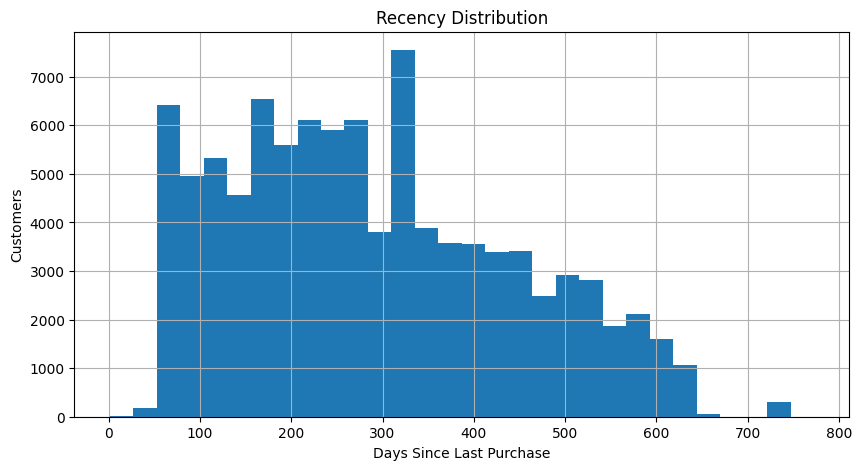

In [120]:
plt.figure(figsize=(10,5))
rfm['Recency'].hist(bins=30)

plt.title('Recency Distribution')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Customers')

plt.show()

# Frequency

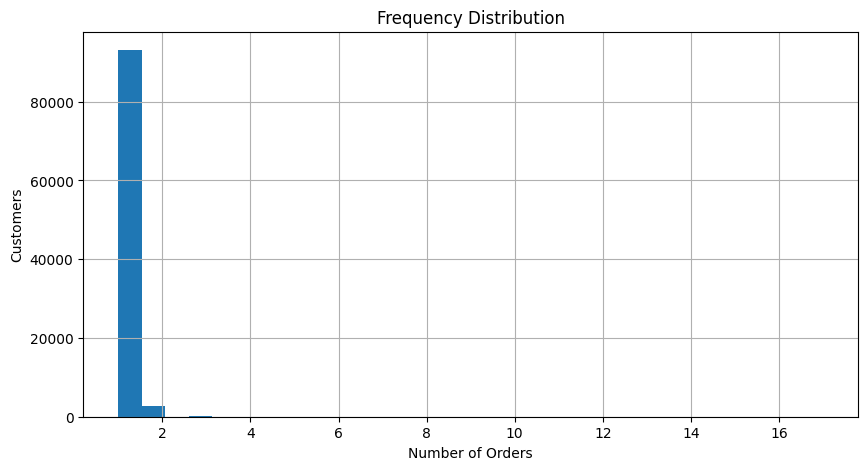

In [121]:
plt.figure(figsize=(10,5))
rfm['Frequency'].hist(bins=30)

plt.title('Frequency Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Customers')

plt.show()

# Monetary

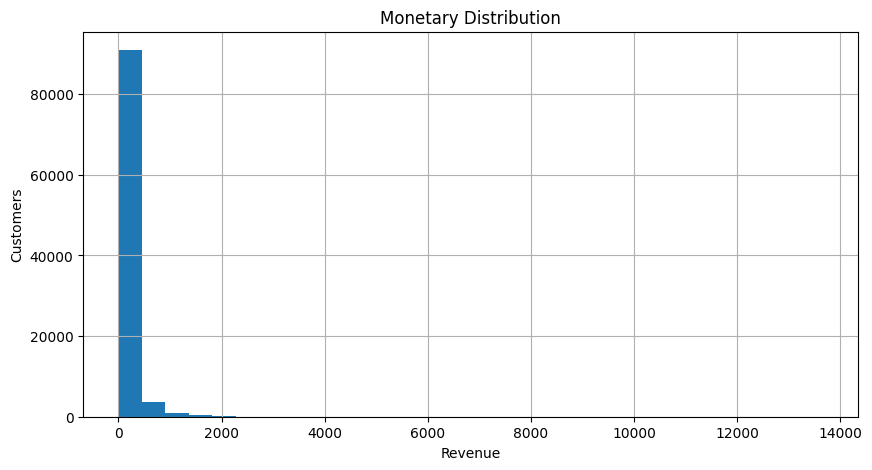

In [122]:
plt.figure(figsize=(10,5))
rfm['Monetary'].hist(bins=30)

plt.title('Monetary Distribution')
plt.xlabel('Revenue')
plt.ylabel('Customers')

plt.show()

# RFM Score Creation

In [123]:
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

# RFM Score

In [124]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,214


# Segment Mapping

In [125]:
def segment_customer(row):

    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    elif r >= 3 and f >= 4:
        return 'Loyal Customers'

    elif r >= 4 and f >= 2:
        return 'Potential Loyalists'

    elif r <= 2 and f >= 3:
        return 'At Risk'

    elif r <= 2 and f <= 2:
        return 'Lost Customers'

    else:
        return 'Others'

In [126]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Number of customers in each segment

In [128]:
segment_count = (
    rfm['Segment']
    .value_counts()
)

segment_count

Segment
At Risk                22967
Others                 19063
Loyal Customers        16441
Lost Customers         15463
Potential Loyalists    15450
Champions               6712
Name: count, dtype: int64

# Chart No. 1

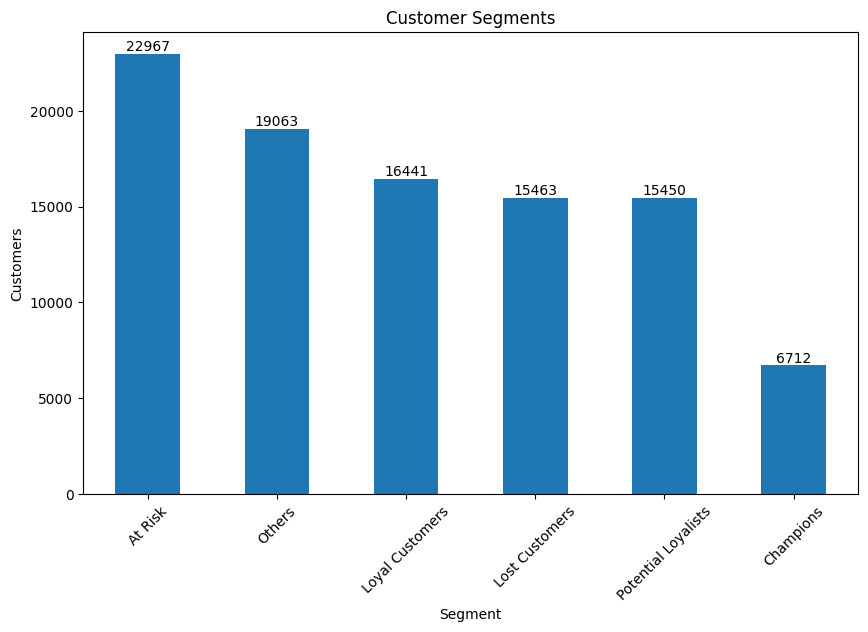

In [129]:
ax = segment_count.plot(
    kind='bar',
    figsize=(10,6)
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Customers')

plt.xticks(rotation=45)

plt.show()

# Chart No. 2
## Percentage of each segment

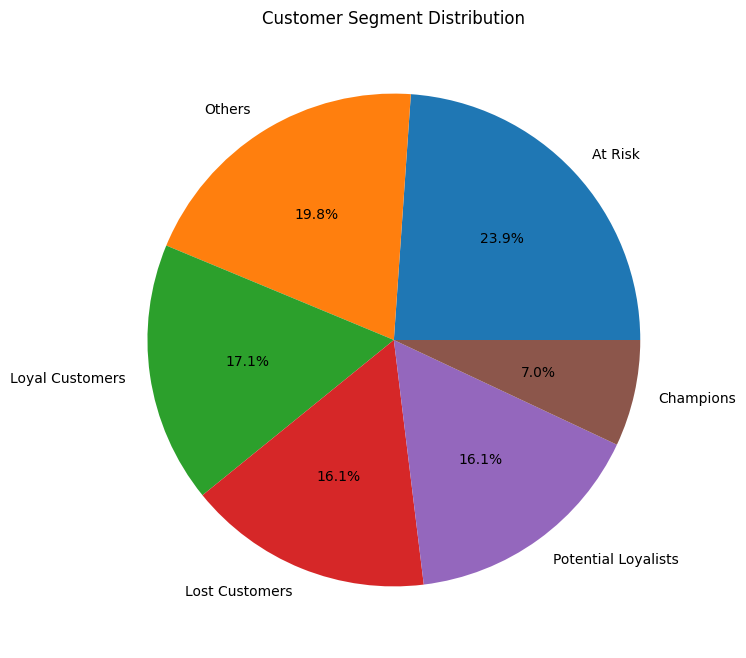

In [130]:
segment_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.ylabel('')
plt.title('Customer Segment Distribution')

plt.show()

# Chart No. 3
## Revenue per segment

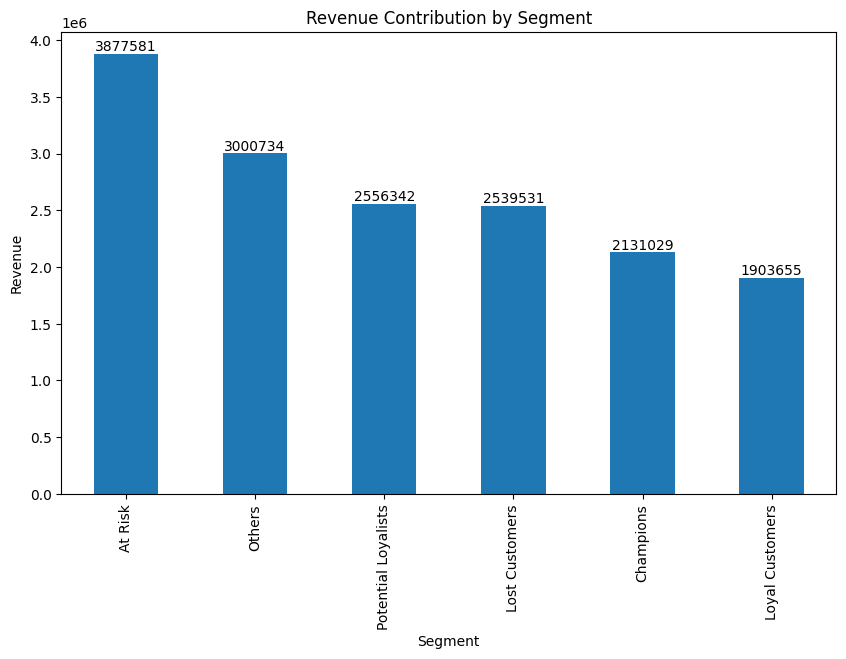

In [131]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

ax = segment_revenue.plot(
    kind='bar',
    figsize=(10,6)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Revenue Contribution by Segment')
plt.ylabel('Revenue')

plt.show()

# Chart No. 4

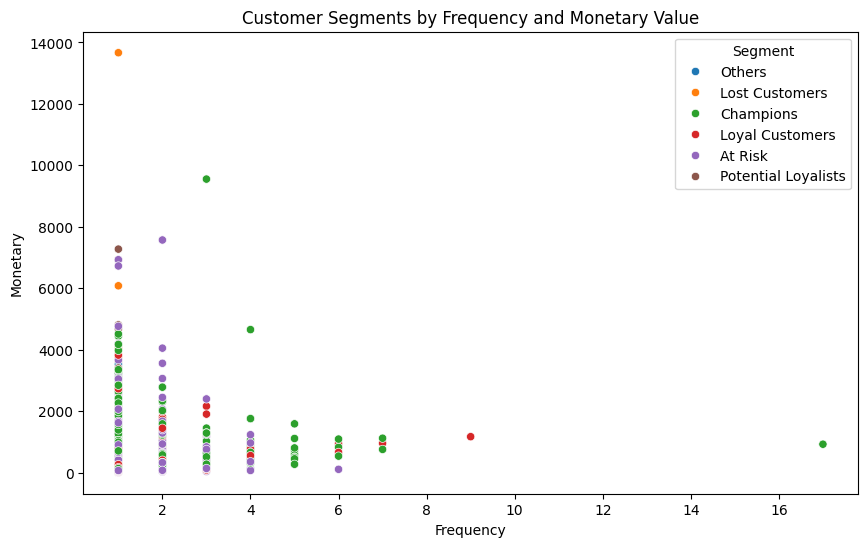

In [132]:

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment'
)

plt.title('Customer Segments by Frequency and Monetary Value')

plt.show()

# Valued Customers Table

In [133]:
champions = (
    rfm[rfm['Segment']=='Champions']
    .sort_values(
        'Monetary',
        ascending=False
    )
)

champions.head(20)

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
26456,46450c74a0d8c5ca9395da1daac6c120,61,3,9553.02,5,5,5,555,Champions
75269,c8460e4251689ba205045f3ea17884a1,71,4,4655.91,5,5,5,555,Champions
89385,edde2314c6c30e864a128ac95d6b2112,75,1,4513.32,5,5,5,555,Champions
60913,a229eba70ec1c2abef51f04987deb7a5,139,1,4445.50,5,4,5,545,Champions
93998,fa562ef24d41361e476e748681810e1e,203,1,4175.26,4,5,5,455,Champions
75984,ca27f3dac28fb1063faddd424c9d95fa,81,1,4163.51,5,4,5,545,Champions
90302,f0767ae738c3d90e7b737d7b8b8bb4d1,157,1,3979.55,4,5,5,455,Champions
77476,ce3fe361f9e68bf0a813baaae1334d01,64,1,3351.35,5,4,5,545,Champions
65407,adfa1cab2b2c8706db21bb13c0a1beb1,138,1,3242.84,5,4,5,545,Champions
70625,bbeb907759ef5fc169099af3c88d535d,174,1,3209.72,4,4,5,445,Champions


# Key Findings

## 1. Customer Distribution

The analysis segmented 99,441 customers into six behavioral groups.

The largest segment is At Risk customers with 22,967 customers,
representing a major opportunity for retention strategies.

---

## 2. High Value Customers

6,712 customers were identified as Champions.

These customers demonstrate strong engagement and high monetary value.

Example:

Customer:
46450c74a0d8c5ca9395da1daac6c120

Frequency:
3 orders

Monetary:
9,553.02 BRL

RFM Score:
555


---

## 3. Retention Opportunity

More than 38,000 customers are either At Risk or Lost.

This highlights the importance of:

- Customer retention campaigns
- Personalized marketing
- Loyalty programs


---

## 4. Growth Opportunity

15,450 Potential Loyalists represent customers who recently engaged and could be converted into long-term customers.